# Sid — Historical Classification Models

Predicting 2024 county-level presidential election winner
using historical voting features + demographic features.

**Input:** `../data/processed/historical_merged_dataset.csv`
**Target:** `party_winner_2024`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### (2) Load dataset

In [2]:
df = pd.read_csv(
    "../data/processed/historical_merged_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"\n2024 target distribution:")
print(df["party_winner_2024"].value_counts().rename({1:"Democrat", 0:"Republican"}))
print(f"\nImbalance ratio: {2661/452:.2f}x")

Shape: (3113, 45)

2024 target distribution:
party_winner_2024
Republican    2661
Democrat       452
Name: count, dtype: int64

Imbalance ratio: 5.89x


### (3) Define feature sets

In [3]:
# Historical political features
hist_features = [
    "dem_share_2000", "dem_share_2004", "dem_share_2008",
    "dem_share_2012", "dem_share_2016", "dem_share_2020",
    "winner_2000", "winner_2004", "winner_2008",
    "winner_2012", "winner_2016", "winner_2020",
    "dem_wins_count", "avg_dem_share", "dem_share_trend",
    "momentum_2016_2020", "momentum_2012_2016",
    "vote_volatility", "competitive_count"
]

# Demographic features
demo_features = [
    "higher_ed_rate", "poverty_rate", "unemployment_rate",
    "white_pct", "black_pct", "asian_pct",
    "median_income", "log_population", "housing_density"
]

# Interaction features (our addition over Atif)
interaction_features = [
    "edu_x_trend", "white_x_momentum",
    "income_x_volatility", "edu_x_wins"
]

# Full feature set
all_features = hist_features + demo_features + interaction_features

target = "party_winner_2024"

model_df = df[all_features + [target]].dropna()
print(f"Rows after dropping NaN: {len(model_df)}")
print(f"Total features: {len(all_features)}")

Rows after dropping NaN: 3112
Total features: 32


### (4) Train/test split and scaling

In [4]:
X = model_df[all_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nTrain distribution:")
print(y_train.value_counts().rename({1:"Democrat", 0:"Republican"}))
print(f"\nTest distribution:")
print(y_test.value_counts().rename({1:"Democrat", 0:"Republican"}))

Train: (2489, 32) | Test: (623, 32)

Train distribution:
party_winner_2024
Republican    2127
Democrat       362
Name: count, dtype: int64

Test distribution:
party_winner_2024
Republican    533
Democrat       90
Name: count, dtype: int64


### (5) Train all models

In [5]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos,
        random_state=42, eval_metric="logloss", verbosity=0),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting
Trained: XGBoost


### (6) Evaluate all models

In [6]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(y_test, y_pred,
                                   target_names=["Republican", "Democrat"],
                                   output_dict=True)
    results.append({
        "Model":              name,
        "Accuracy":           round(report["accuracy"], 3),
        "Dem F1":             round(report["Democrat"]["f1-score"], 3),
        "Dem Precision":      round(report["Democrat"]["precision"], 3),
        "Dem Recall":         round(report["Democrat"]["recall"], 3),
        "ROC AUC":            round(roc_auc_score(y_test, y_prob), 3),
    })
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred,
                                target_names=["Republican", "Democrat"]))

results_df = pd.DataFrame(results).set_index("Model")
print("\nFULL COMPARISON:")
display(results_df)


Logistic Regression:
              precision    recall  f1-score   support

  Republican       1.00      0.97      0.98       533
    Democrat       0.83      0.99      0.90        90

    accuracy                           0.97       623
   macro avg       0.91      0.98      0.94       623
weighted avg       0.97      0.97      0.97       623


Random Forest:
              precision    recall  f1-score   support

  Republican       0.99      0.98      0.99       533
    Democrat       0.91      0.97      0.94        90

    accuracy                           0.98       623
   macro avg       0.95      0.97      0.96       623
weighted avg       0.98      0.98      0.98       623


Gradient Boosting:
              precision    recall  f1-score   support

  Republican       0.99      0.98      0.99       533
    Democrat       0.92      0.97      0.94        90

    accuracy                           0.98       623
   macro avg       0.96      0.98      0.97       623
weighted avg    

,Accuracy,Dem F1,Dem Precision,Dem Recall,ROC AUC
Model,,,,,
Logistic Regression,0.970,0.904,0.832,0.989,0.996
Random Forest,0.981,0.935,0.906,0.967,0.998
Gradient Boosting,0.982,0.941,0.916,0.967,0.998
XGBoost,0.986,0.952,0.918,0.989,0.998


### (7) Ablation — demographics only vs full features

In [7]:
# Train Random Forest on demographics only — no historical features
X_demo_train = X_train[demo_features]
X_demo_test  = X_test[demo_features]

scaler_demo = StandardScaler()
X_demo_train_scaled = scaler_demo.fit_transform(X_demo_train)
X_demo_test_scaled  = scaler_demo.transform(X_demo_test)

rf_demo = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_demo.fit(X_demo_train_scaled, y_train)
y_pred_demo = rf_demo.predict(X_demo_test_scaled)
y_prob_demo = rf_demo.predict_proba(X_demo_test_scaled)[:, 1]

report_demo = classification_report(y_test, y_pred_demo,
                                    target_names=["Republican", "Democrat"],
                                    output_dict=True)

print("Demographics Only — Random Forest:")
print(classification_report(y_test, y_pred_demo,
                            target_names=["Republican", "Democrat"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_demo):.3f}")

print("\nComparison — Full Features vs Demographics Only:")
print(f"  Full RF Accuracy:  {results_df.loc['Random Forest','Accuracy']} "
      f"vs Demo Only: {round(report_demo['accuracy'],3)}")
print(f"  Full RF Dem F1:    {results_df.loc['Random Forest','Dem F1']} "
      f"vs Demo Only: {round(report_demo['Democrat']['f1-score'],3)}")
print(f"  Full RF AUC:       {results_df.loc['Random Forest','ROC AUC']} "
      f"vs Demo Only: {round(roc_auc_score(y_test, y_prob_demo),3)}")

Demographics Only — Random Forest:
              precision    recall  f1-score   support

  Republican       0.94      0.98      0.96       533
    Democrat       0.87      0.64      0.74        90

    accuracy                           0.93       623
   macro avg       0.90      0.81      0.85       623
weighted avg       0.93      0.93      0.93       623

ROC AUC: 0.960

Comparison — Full Features vs Demographics Only:
  Full RF Accuracy:  0.981 vs Demo Only: 0.934
  Full RF Dem F1:    0.935 vs Demo Only: 0.739
  Full RF AUC:       0.998 vs Demo Only: 0.96


### (8) ROC curves

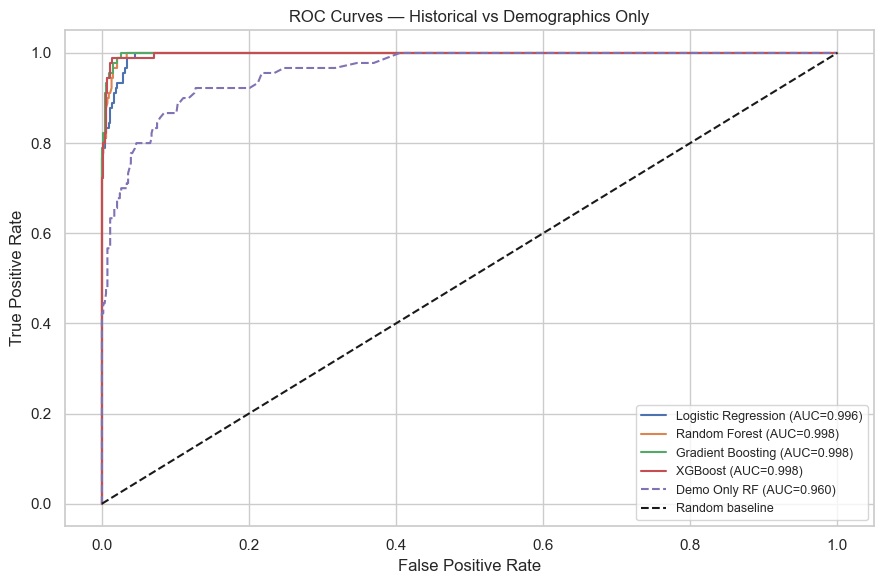

In [8]:
plt.figure(figsize=(9, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# Demographics only
fpr_d, tpr_d, _ = roc_curve(y_test, y_prob_demo)
auc_d = roc_auc_score(y_test, y_prob_demo)
plt.plot(fpr_d, tpr_d, linestyle="--",
         label=f"Demo Only RF (AUC={auc_d:.3f})")

plt.plot([0,1],[0,1],"k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Historical vs Demographics Only")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### (9) Feature importance — top 20

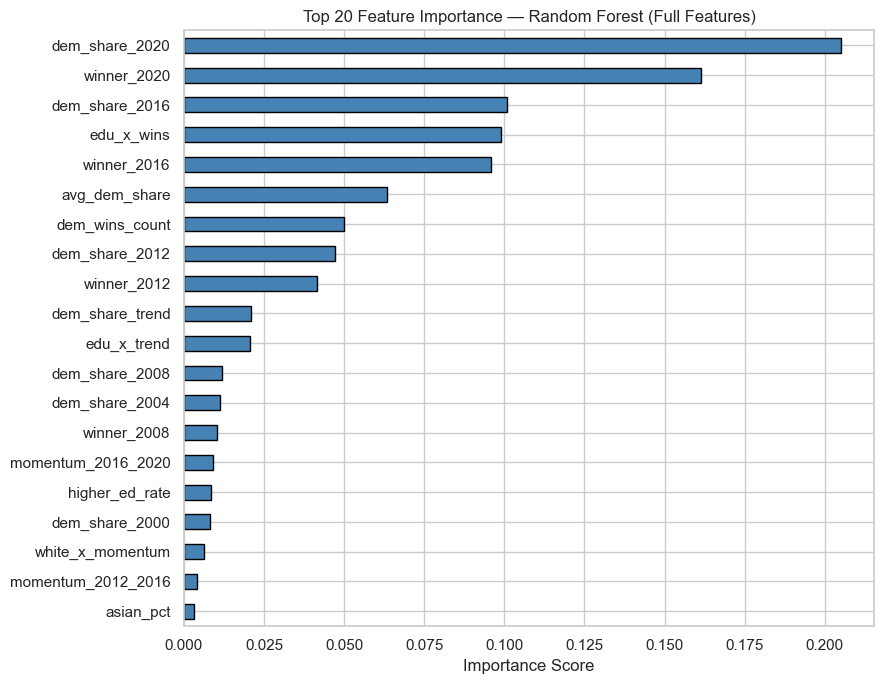


Top 20 features:
dem_share_2020        0.2051
winner_2020           0.1614
dem_share_2016        0.1009
edu_x_wins            0.0991
winner_2016           0.0957
avg_dem_share         0.0633
dem_wins_count        0.0500
dem_share_2012        0.0472
winner_2012           0.0416
dem_share_trend       0.0210
edu_x_trend           0.0205
dem_share_2008        0.0118
dem_share_2004        0.0112
winner_2008           0.0104
momentum_2016_2020    0.0091
higher_ed_rate        0.0084
dem_share_2000        0.0080
white_x_momentum      0.0063
momentum_2012_2016    0.0040
asian_pct             0.0033
dtype: float64


In [9]:
rf_model = models["Random Forest"]

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=all_features
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
feat_imp.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 20 Feature Importance — Random Forest (Full Features)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
print(feat_imp.round(4))

### (10) Confusion matrices

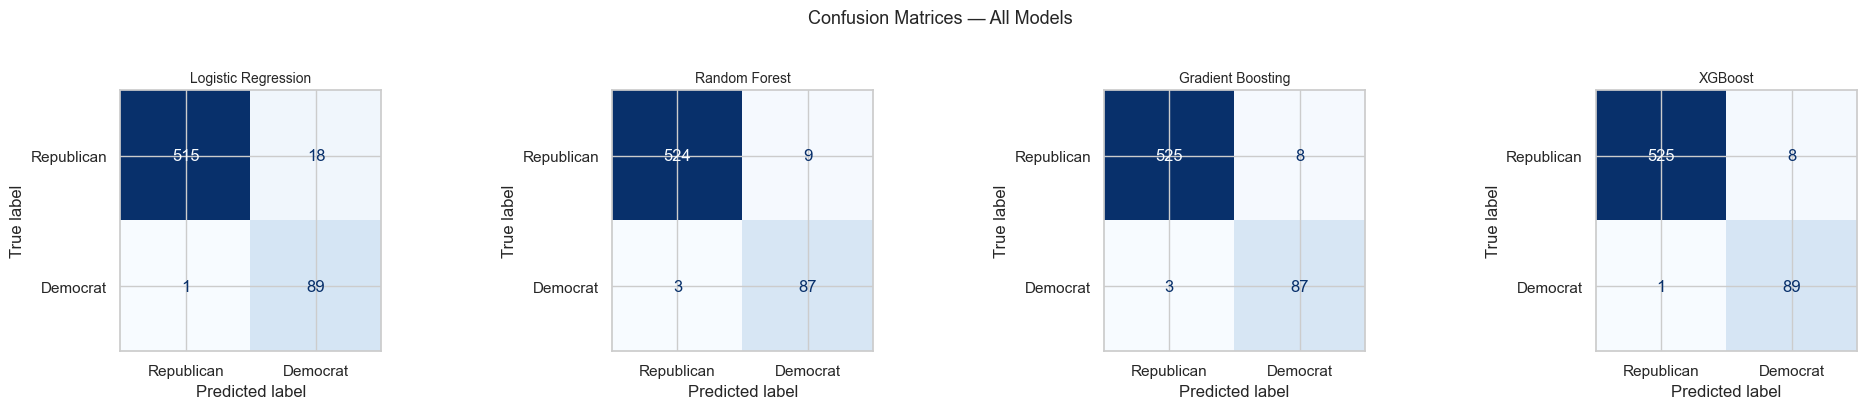

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Republican", "Democrat"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)

plt.suptitle("Confusion Matrices — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### (11) Summary

In [11]:
best = results_df["Dem F1"].idxmax()

print("=" * 55)
print("HISTORICAL CLASSIFICATION SUMMARY")
print("=" * 55)
print(f"Training years:     2000–2020")
print(f"Test target:        2024 election")
print(f"Total features:     {len(all_features)}")
print(f"  Historical:       {len(hist_features)}")
print(f"  Demographic:      {len(demo_features)}")
print(f"  Interaction:      {len(interaction_features)}")
print(f"\nBest model:         {best}")
print(f"Accuracy:           {results_df.loc[best,'Accuracy']}")
print(f"Democrat F1:        {results_df.loc[best,'Dem F1']}")
print(f"ROC AUC:            {results_df.loc[best,'ROC AUC']}")
print(f"\nKey insight: Historical features dominate prediction.")
print(f"Demographics-only performance is significantly lower,")
print(f"confirming past voting behavior is the strongest predictor.")
print("=" * 55)

HISTORICAL CLASSIFICATION SUMMARY
Training years:     2000–2020
Test target:        2024 election
Total features:     32
  Historical:       19
  Demographic:      9
  Interaction:      4

Best model:         XGBoost
Accuracy:           0.986
Democrat F1:        0.952
ROC AUC:            0.998

Key insight: Historical features dominate prediction.
Demographics-only performance is significantly lower,
confirming past voting behavior is the strongest predictor.
